In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import optuna
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

In [125]:
import xgboost
import lightgbm
import catboost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [126]:
train_df = pd.read_csv("cs-training.csv")

In [127]:
train_df.sample(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
73986,73987,0,1.000000,32,0,0.747305,5286.0,6,0,2,0,2.0
62918,62919,0,0.210335,56,1,0.489114,8083.0,31,0,2,0,4.0
5112,5113,0,0.006928,62,0,0.002666,6000.0,7,0,0,0,0.0
53220,53221,0,0.032426,69,0,232.500000,1.0,3,0,0,0,0.0
143243,143244,0,0.021866,69,0,0.400088,6800.0,20,0,2,0,0.0
61054,61055,0,0.033073,44,0,0.239960,6000.0,8,0,1,0,0.0
94120,94121,0,0.383680,57,0,0.224431,8300.0,7,0,1,1,2.0
58715,58716,0,0.948256,32,0,0.565856,8715.0,11,0,4,0,1.0
35870,35871,0,0.528236,32,0,0.264636,1673.0,4,0,0,0,0.0
28508,28509,0,0.044041,48,1,0.276831,10500.0,4,0,2,0,2.0


In [128]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [129]:
train_df.shape

(150000, 12)

In [130]:
train_df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [131]:
train_df.duplicated().sum()

np.int64(0)

In [132]:
train_df.corr()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Unnamed: 0,1.000000,0.002801,0.002372,0.004403,-0.000571,-0.002906,0.002632,0.004586,-0.001104,-0.000666,-0.000777,-0.000055
SeriousDlqin2yrs,0.002801,1.000000,-0.001802,-0.115386,0.125587,-0.007602,-0.019746,-0.029669,0.117175,-0.007038,0.102261,0.046048
RevolvingUtilizationOfUnsecuredLines,0.002372,-0.001802,1.000000,-0.005898,-0.001314,0.003961,0.007124,-0.011281,-0.001061,0.006235,-0.001048,0.001557
age,0.004403,-0.115386,-0.005898,1.000000,-0.062995,0.024188,0.037717,0.147705,-0.061005,0.033150,-0.057159,-0.213303
NumberOfTime30-59DaysPastDueNotWorse,-0.000571,0.125587,-0.001314,-0.062995,1.000000,-0.006542,-0.010217,-0.055312,0.983603,-0.030565,0.987005,-0.002680
DebtRatio,-0.002906,-0.007602,0.003961,0.024188,-0.006542,1.000000,-0.028712,0.049565,-0.008320,0.120046,-0.007533,-0.040673
MonthlyIncome,0.002632,-0.019746,0.007124,0.037717,-0.010217,-0.028712,1.000000,0.091455,-0.012743,0.124959,-0.011116,0.062647
NumberOfOpenCreditLinesAndLoans,0.004586,-0.029669,-0.011281,0.147705,-0.055312,0.049565,0.091455,1.000000,-0.079984,0.433959,-0.071077,0.065322
NumberOfTimes90DaysLate,-0.001104,0.117175,-0.001061,-0.061005,0.983603,-0.008320,-0.012743,-0.079984,1.000000,-0.045205,0.992796,-0.010176
NumberRealEstateLoansOrLines,-0.000666,-0.007038,0.006235,0.033150,-0.030565,0.120046,0.124959,0.433959,-0.045205,1.000000,-0.039722,0.124684


In [133]:
train_df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [134]:
train_df.groupby('age')[["DebtRatio",'SeriousDlqin2yrs']].mean().sort_values(by='DebtRatio',ascending=False)

,DebtRatio,SeriousDlqin2yrs
age,,
109,1229.500000,0.000000
107,939.000000,0.000000
65,772.902453,0.035466
103,601.166667,0.000000
58,528.222826,0.047633
...,...,...
97,3.133464,0.000000
105,2.000000,0.000000
0,0.436927,0.000000


In [135]:
train_df.groupby('NumberOfDependents')[["DebtRatio",'SeriousDlqin2yrs']].mean().sort_values(by =['SeriousDlqin2yrs','DebtRatio'],ascending=[False,False])

,DebtRatio,SeriousDlqin2yrs
NumberOfDependents,,
6.0,126.818586,0.151899
4.0,212.753479,0.103774
7.0,144.332806,0.098039
5.0,198.931910,0.091153
3.0,228.205045,0.088263
8.0,88.093734,0.083333
2.0,242.657069,0.081139
1.0,174.621397,0.073529
0.0,418.946560,0.058629


In [136]:
train_df.groupby('MonthlyIncome')[["RevolvingUtilizationOfUnsecuredLines",'SeriousDlqin2yrs']].mean().sort_values(by =['MonthlyIncome','SeriousDlqin2yrs'],ascending=[False,False])

,RevolvingUtilizationOfUnsecuredLines,SeriousDlqin2yrs
MonthlyIncome,,
3008750.0,0.007328,0.000000
1794060.0,0.000000,0.000000
1560100.0,0.163856,0.000000
1072500.0,0.469025,0.000000
835040.0,0.041599,0.000000
...,...,...
5.0,0.000000,0.000000
4.0,0.374554,0.500000
2.0,0.721738,0.000000


In [137]:
train_df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [138]:
train_df = train_df.drop(columns=["Unnamed: 0"], errors="ignore")

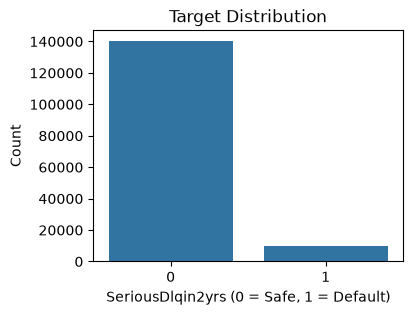

In [139]:
plt.figure(figsize=(4,3))
sns.countplot(x="SeriousDlqin2yrs", data=train_df)

plt.title("Target Distribution")
plt.xlabel("SeriousDlqin2yrs (0 = Safe, 1 = Default)")
plt.ylabel("Count")

plt.show()

In [140]:
features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "age"
]

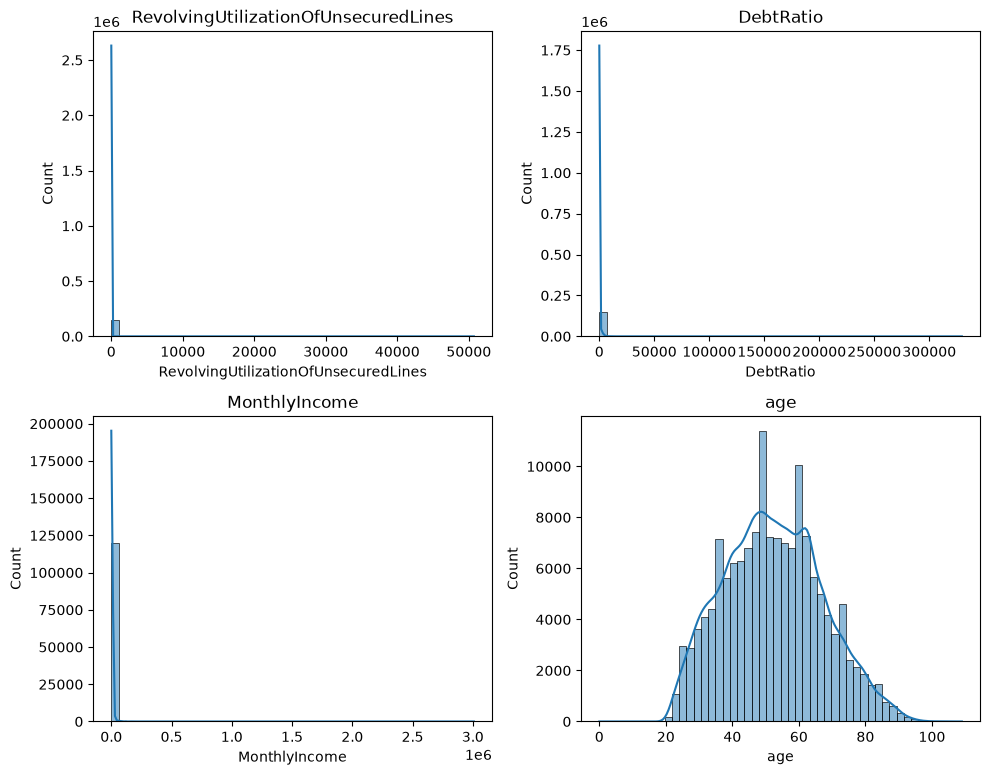

In [141]:
plt.figure(figsize=(10,8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(train_df[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

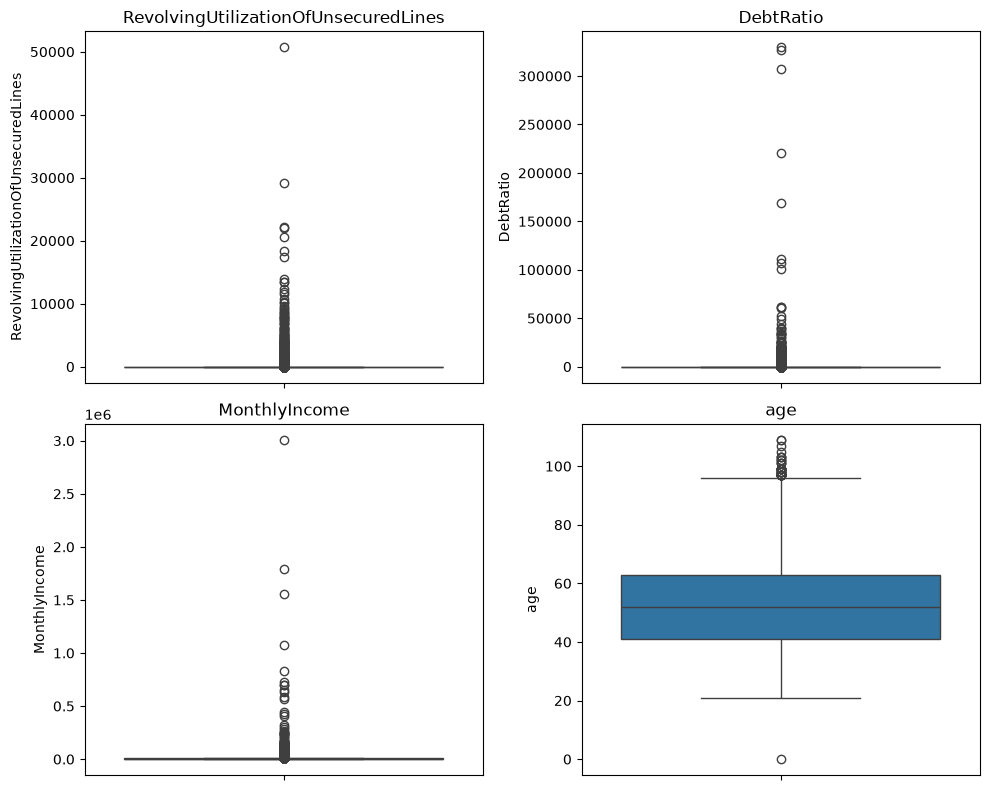

In [142]:
plt.figure(figsize=(10,8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(train_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [143]:
for col in features:
    upper_limit = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(upper=upper_limit)

In [144]:
train_df[features].max()

RevolvingUtilizationOfUnsecuredLines        1.092956
DebtRatio                                4979.040000
MonthlyIncome                           25000.000000
age                                        87.000000
dtype: float64

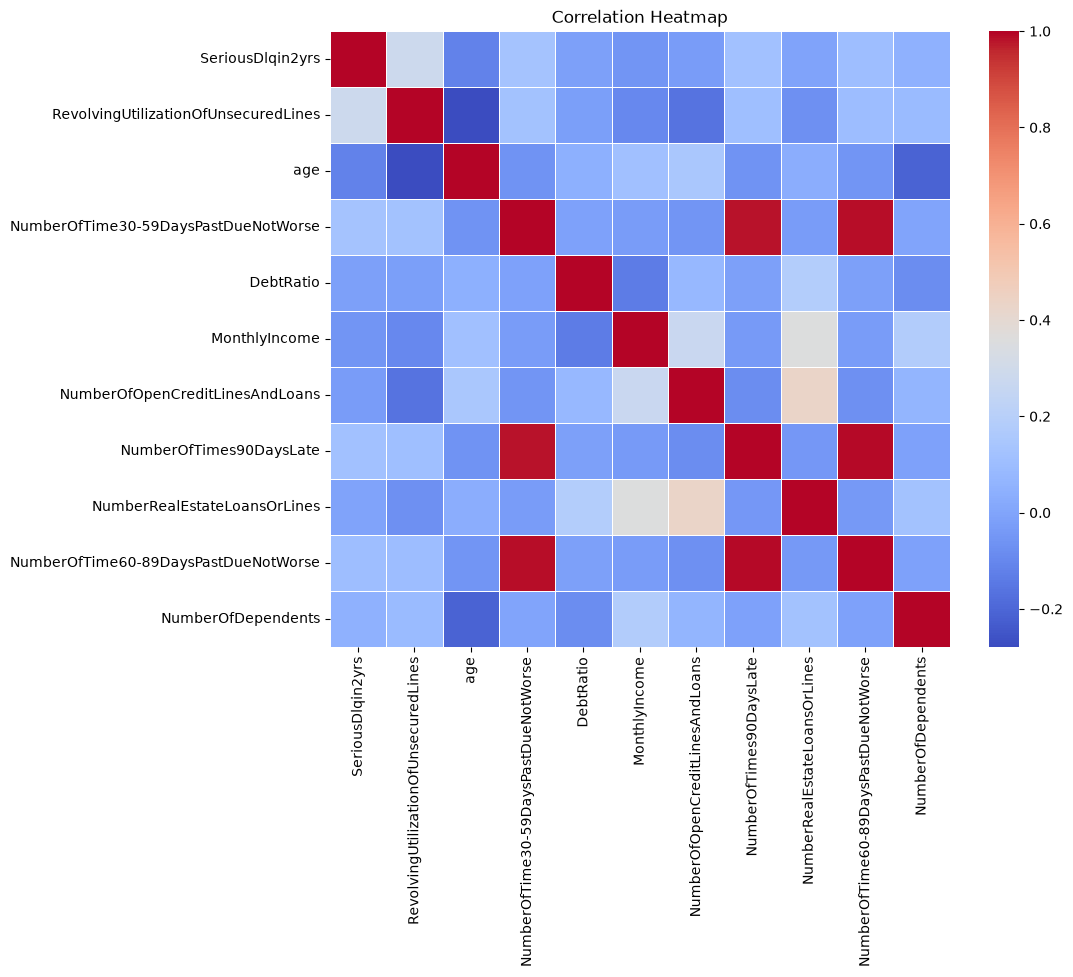

In [145]:
plt.figure(figsize=(10,8))

corr_matrix = train_df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [146]:
y = train_df["SeriousDlqin2yrs"]

X = train_df.drop(columns=["SeriousDlqin2yrs"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150000, 10)
y shape: (150000,)


In [147]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120000, 10)
X_test: (30000, 10)
y_train: (120000,)
y_test: (30000,)


In [148]:
x_train

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
57836,0.114987,62,0,1841.000000,NaN,5,0,1,0,2.0
132895,0.008705,73,0,0.498553,3800.0,6,0,1,0,0.0
27981,0.214501,32,0,0.211999,3716.0,8,0,0,0,2.0
37852,1.000000,60,0,118.000000,NaN,5,0,0,0,0.0
103813,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...
18048,0.004136,41,0,0.472323,7695.0,9,0,2,0,0.0
3895,0.000000,49,0,0.322344,8583.0,18,0,1,0,1.0
109980,1.000000,80,0,35.000000,NaN,0,0,0,0,0.0
74354,0.925187,63,0,0.389974,1535.0,2,1,0,0,0.0


In [149]:
x_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           23675
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3128
dtype: int64

In [150]:
from feature_engineering import FeatureEngineer
x_train_fe = FeatureEngineer().fit_transform(x_train)
x_test_fe = FeatureEngineer().transform(x_test)

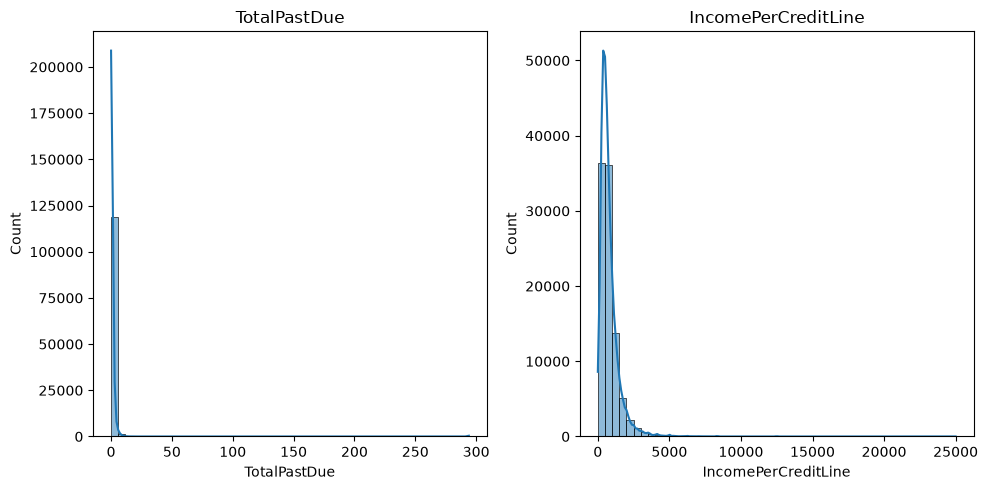

In [151]:
engineered_features = ["TotalPastDue", "IncomePerCreditLine"]

plt.figure(figsize=(10,5))
for i, col in enumerate(engineered_features, 1):
    plt.subplot(1, 2, i)
    sns.histplot(x_train_fe[col], bins=50, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

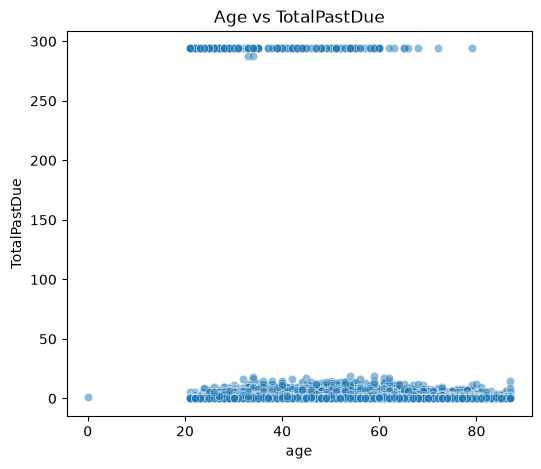

In [152]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="age",
    y="TotalPastDue",
    data=x_train_fe,
    alpha=0.5
)
plt.title("Age vs TotalPastDue")
plt.show()

In [153]:
x_train_fe.dtypes

RevolvingUtilizationOfUnsecuredLines     float64
age                                        int64
NumberOfTime30-59DaysPastDueNotWorse       int64
DebtRatio                                float64
MonthlyIncome                            float64
NumberOfOpenCreditLinesAndLoans            int64
NumberOfTimes90DaysLate                    int64
NumberRealEstateLoansOrLines               int64
NumberOfTime60-89DaysPastDueNotWorse       int64
NumberOfDependents                       float64
TotalPastDue                               int64
IncomePerCreditLine                      float64
AgeGroup                                category
dtype: object

In [154]:
num_cols = x_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = x_train_fe.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

In [155]:
num_cols

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'TotalPastDue',
 'IncomePerCreditLine']

In [156]:
cat_cols

['AgeGroup']

In [157]:
skew_values = x_train_fe[num_cols].skew()
skew_values.sort_values(ascending=False)

NumberOfTime60-89DaysPastDueNotWorse    23.393891
TotalPastDue                            23.342142
NumberOfTimes90DaysLate                 23.155874
NumberOfTime30-59DaysPastDueNotWorse    22.656728
IncomePerCreditLine                      5.843250
NumberRealEstateLoansOrLines             3.752688
DebtRatio                                3.354025
MonthlyIncome                            1.606668
NumberOfDependents                       1.598577
NumberOfOpenCreditLinesAndLoans          1.228647
RevolvingUtilizationOfUnsecuredLines     0.907088
age                                      0.156402
dtype: float64

In [158]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

In [159]:
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[[
            "20-30",
            "30-40",
            "40-50",
            "50-60",
            "60-70",
            "70+"
        ]]
    ))
])

In [160]:
trans = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
], remainder='passthrough',verbose_feature_names_out=False)

trans.set_output(transform='pandas')
pipe1 = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", trans),
    ("smote", SMOTE(random_state=42))
])
pipe1.fit(x_train, y_train)

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details

In [161]:
x_train_transformed = pipe1.named_steps["preprocessor"].transform(x_train_fe)
skew_after = x_train_transformed.skew().sort_values(ascending=False)
print(skew_after)

NumberOfTime60-89DaysPastDueNotWorse    4.082303
NumberOfTimes90DaysLate                 3.867039
NumberOfTime30-59DaysPastDueNotWorse    1.854483
TotalPastDue                            1.482700
DebtRatio                               1.230078
NumberOfDependents                      0.442441
IncomePerCreditLine                     0.347864
RevolvingUtilizationOfUnsecuredLines    0.309029
MonthlyIncome                           0.138614
NumberRealEstateLoansOrLines            0.045673
NumberOfOpenCreditLinesAndLoans         0.008358
AgeGroup                               -0.037812
age                                    -0.040685
dtype: float64


In [162]:
pipe1.named_steps

{'feature_engineering': FeatureEngineer(),
 'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('num',
                                  Pipeline(steps=[('imputer', SimpleImputer()),
                                                  ('power', PowerTransformer()),
                                                  ('scaler', StandardScaler())]),
                                  ['RevolvingUtilizationOfUnsecuredLines', 'age',
                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                   'DebtRatio', 'MonthlyIncome',
                                   'NumberOfOpenCreditLinesAndLoans',
                                   'NumberOfTimes90DaysLate',
                                   'NumberRealEstateLoansOrLines',
                                   'NumberOfTime60-89DaysPastDueNotWorse',
                                   'NumberOfDependents', 'TotalPastDue',
                                   'IncomePe

In [109]:
print(x_train_fe["AgeGroup"].isnull().sum())

0


In [270]:
def objective(trial, classifier_name):
    
  if classifier_name == 'LogisticRegression':
    l1_ratio = trial.suggest_categorical('l1_ratio',[0])
    solver = trial.suggest_categorical('solver',['lbfgs','newton-cholesky','newton-cg','sag','saga'])

    model = LogisticRegression(
        max_iter=5000,
        l1_ratio=l1_ratio,
        solver=solver
    )

  elif classifier_name == 'RandomForest':
    n_estimators = trial.suggest_int('n_estimators',50,100)
    max_depth = trial.suggest_int('max_depth',3,10)
    criterion = trial.suggest_categorical("criterion",['gini','entropy','log_loss'])

    model = RandomForestClassifier(
        random_state=42,
        n_estimators=n_estimators
        ,max_depth=max_depth,
        criterion=criterion
    )

  elif classifier_name == 'KNN':
    n_neighbors = trial.suggest_int('n_neighbors',3,5)
    algorithm = trial.suggest_categorical('algorithm',['auto','ball_tree','brute'])

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        algorithm=algorithm
    )


  elif classifier_name == 'DecisionTree':
    max_depth = trial.suggest_int('max_depth',3,10)
    criterion = trial.suggest_categorical("criterion",['gini','entropy','log_loss'])

    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=max_depth,
        criterion=criterion
    )

  elif classifier_name == 'XGBoost':

    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=50)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    gamma = trial.suggest_float('gamma', 0, 5)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight
    )

  elif classifier_name == 'LightGBM':

    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=50)
    num_leaves = trial.suggest_int('num_leaves', 20, 100)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)

    model = LGBMClassifier(
        random_state=42,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        num_leaves=num_leaves,
        subsample=subsample,
        colsample_bytree=colsample_bytree
    )

  elif classifier_name == 'CatBoost':

    depth = trial.suggest_int('depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    iterations = trial.suggest_int('iterations', 100, 500, step=50)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10)
    random_strength = trial.suggest_float('random_strength', 0, 10)

    model = CatBoostClassifier(
        random_state=42,
        verbose=0,
        depth=depth,
        learning_rate=learning_rate,
        iterations=iterations,
        l2_leaf_reg=l2_leaf_reg,
        random_strength=random_strength
    )
  pipe2 = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", trans),
    ("smote", SMOTE(random_state=42)),
    ("model", model)
      ])
  scores = cross_validate(
    pipe2,
    x_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1
)

  return scores['test_roc_auc'].mean()

In [271]:
models = [
    "LogisticRegression",
    "RandomForest",
    "KNN",
    "DecisionTree", 
    "XGBoost",
    "LightGBM",
    "CatBoost"
]
studies = {}
for model_name in models:
    print("="*50)
    print("Optimizing:", model_name)
    study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, model_name),n_trials=20,show_progress_bar=True)
    studies[model_name] = study

[I 2026-08-02 15:54:28,501] A new study created in memory with name: no-name-a28b5877-afe9-4ec3-9a2f-25f1eb3d4810


Optimizing: LogisticRegression


Best trial: 0. Best value: 0.79905:  10%|█         | 1/10 [00:02<00:24,  2.69s/it]

[I 2026-08-02 15:54:31,212] Trial 0 finished with value: 0.7990499999999999 and parameters: {'l1_ratio': 0, 'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.7990499999999999.


Best trial: 0. Best value: 0.79905:  20%|██        | 2/10 [00:05<00:20,  2.51s/it]

[I 2026-08-02 15:54:33,605] Trial 1 finished with value: 0.7990416666666667 and parameters: {'l1_ratio': 0, 'solver': 'newton-cg'}. Best is trial 0 with value: 0.7990499999999999.


Best trial: 0. Best value: 0.79905:  30%|███       | 3/10 [00:07<00:16,  2.38s/it]

[I 2026-08-02 15:54:35,815] Trial 2 finished with value: 0.7990499999999999 and parameters: {'l1_ratio': 0, 'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.7990499999999999.


Best trial: 0. Best value: 0.79905:  40%|████      | 4/10 [00:09<00:14,  2.38s/it]

[I 2026-08-02 15:54:38,202] Trial 3 finished with value: 0.7990416666666667 and parameters: {'l1_ratio': 0, 'solver': 'newton-cg'}. Best is trial 0 with value: 0.7990499999999999.


Best trial: 0. Best value: 0.79905:  50%|█████     | 5/10 [00:12<00:11,  2.37s/it]

[I 2026-08-02 15:54:40,549] Trial 4 finished with value: 0.7990166666666667 and parameters: {'l1_ratio': 0, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7990499999999999.


Best trial: 0. Best value: 0.79905:  60%|██████    | 6/10 [00:14<00:09,  2.33s/it]

[I 2026-08-02 15:54:42,819] Trial 5 finished with value: 0.7990166666666667 and parameters: {'l1_ratio': 0, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7990499999999999.


Best trial: 6. Best value: 0.799058:  70%|███████   | 7/10 [00:16<00:07,  2.44s/it]

[I 2026-08-02 15:54:45,478] Trial 6 finished with value: 0.7990583333333334 and parameters: {'l1_ratio': 0, 'solver': 'saga'}. Best is trial 6 with value: 0.7990583333333334.


Best trial: 6. Best value: 0.799058:  80%|████████  | 8/10 [00:19<00:04,  2.39s/it]

[I 2026-08-02 15:54:47,750] Trial 7 finished with value: 0.7990166666666667 and parameters: {'l1_ratio': 0, 'solver': 'lbfgs'}. Best is trial 6 with value: 0.7990583333333334.


Best trial: 8. Best value: 0.799067:  90%|█████████ | 9/10 [00:20<00:02,  2.12s/it]

[I 2026-08-02 15:54:49,270] Trial 8 finished with value: 0.7990666666666667 and parameters: {'l1_ratio': 0, 'solver': 'sag'}. Best is trial 8 with value: 0.7990666666666667.


Best trial: 8. Best value: 0.799067: 100%|██████████| 10/10 [00:21<00:00,  2.17s/it]
[I 2026-08-02 15:54:50,249] A new study created in memory with name: no-name-d3ef388e-ab5a-4693-81c1-9ac4d2d3dd82


[I 2026-08-02 15:54:50,245] Trial 9 finished with value: 0.7990166666666667 and parameters: {'l1_ratio': 0, 'solver': 'lbfgs'}. Best is trial 8 with value: 0.7990666666666667.
Optimizing: RandomForest


Best trial: 0. Best value: 0.8512:  10%|█         | 1/10 [00:07<01:04,  7.16s/it]

[I 2026-08-02 15:54:57,403] Trial 0 finished with value: 0.8512 and parameters: {'n_estimators': 69, 'max_depth': 10, 'criterion': 'gini'}. Best is trial 0 with value: 0.8512.


Best trial: 1. Best value: 0.8703:  20%|██        | 2/10 [00:10<00:37,  4.72s/it]

[I 2026-08-02 15:55:00,425] Trial 1 finished with value: 0.8703 and parameters: {'n_estimators': 57, 'max_depth': 3, 'criterion': 'gini'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  30%|███       | 3/10 [00:15<00:35,  5.03s/it]

[I 2026-08-02 15:55:05,820] Trial 2 finished with value: 0.8520583333333334 and parameters: {'n_estimators': 51, 'max_depth': 10, 'criterion': 'gini'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  40%|████      | 4/10 [00:19<00:28,  4.69s/it]

[I 2026-08-02 15:55:09,977] Trial 3 finished with value: 0.8342333333333333 and parameters: {'n_estimators': 59, 'max_depth': 5, 'criterion': 'gini'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  50%|█████     | 5/10 [00:25<00:24,  4.97s/it]

[I 2026-08-02 15:55:15,440] Trial 4 finished with value: 0.808325 and parameters: {'n_estimators': 81, 'max_depth': 4, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  60%|██████    | 6/10 [00:31<00:21,  5.35s/it]

[I 2026-08-02 15:55:21,549] Trial 5 finished with value: 0.8085416666666667 and parameters: {'n_estimators': 90, 'max_depth': 4, 'criterion': 'entropy'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  70%|███████   | 7/10 [00:36<00:16,  5.43s/it]

[I 2026-08-02 15:55:27,149] Trial 6 finished with value: 0.8113416666666667 and parameters: {'n_estimators': 80, 'max_depth': 4, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  80%|████████  | 8/10 [00:44<00:12,  6.20s/it]

[I 2026-08-02 15:55:34,987] Trial 7 finished with value: 0.8361666666666666 and parameters: {'n_estimators': 91, 'max_depth': 5, 'criterion': 'entropy'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703:  90%|█████████ | 9/10 [00:50<00:06,  6.02s/it]

[I 2026-08-02 15:55:40,610] Trial 8 finished with value: 0.8318666666666666 and parameters: {'n_estimators': 56, 'max_depth': 6, 'criterion': 'entropy'}. Best is trial 1 with value: 0.8703.


Best trial: 1. Best value: 0.8703: 100%|██████████| 10/10 [00:57<00:00,  5.73s/it]
[I 2026-08-02 15:55:47,588] A new study created in memory with name: no-name-d749a414-4455-43b3-a136-455437ac941c


[I 2026-08-02 15:55:47,585] Trial 9 finished with value: 0.8367666666666667 and parameters: {'n_estimators': 83, 'max_depth': 5, 'criterion': 'entropy'}. Best is trial 1 with value: 0.8703.
Optimizing: DecisionTree


Best trial: 0. Best value: 0.7842:  10%|█         | 1/10 [00:01<00:10,  1.12s/it]

[I 2026-08-02 15:55:48,710] Trial 0 finished with value: 0.7841999999999999 and parameters: {'max_depth': 5, 'criterion': 'gini'}. Best is trial 0 with value: 0.7841999999999999.


Best trial: 1. Best value: 0.815717:  20%|██        | 2/10 [00:02<00:09,  1.15s/it]

[I 2026-08-02 15:55:49,877] Trial 1 finished with value: 0.8157166666666668 and parameters: {'max_depth': 4, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.8157166666666668.


Best trial: 1. Best value: 0.815717:  30%|███       | 3/10 [00:03<00:08,  1.24s/it]

[I 2026-08-02 15:55:51,230] Trial 2 finished with value: 0.8031416666666665 and parameters: {'max_depth': 7, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.8157166666666668.


Best trial: 3. Best value: 0.824333:  40%|████      | 4/10 [00:05<00:07,  1.30s/it]

[I 2026-08-02 15:55:52,628] Trial 3 finished with value: 0.8243333333333333 and parameters: {'max_depth': 9, 'criterion': 'gini'}. Best is trial 3 with value: 0.8243333333333333.


Best trial: 3. Best value: 0.824333:  50%|█████     | 5/10 [00:06<00:06,  1.24s/it]

[I 2026-08-02 15:55:53,762] Trial 4 finished with value: 0.7841999999999999 and parameters: {'max_depth': 5, 'criterion': 'gini'}. Best is trial 3 with value: 0.8243333333333333.


Best trial: 3. Best value: 0.824333:  60%|██████    | 6/10 [00:07<00:05,  1.27s/it]

[I 2026-08-02 15:55:55,072] Trial 5 finished with value: 0.8031416666666665 and parameters: {'max_depth': 7, 'criterion': 'log_loss'}. Best is trial 3 with value: 0.8243333333333333.


Best trial: 3. Best value: 0.824333:  70%|███████   | 7/10 [00:08<00:03,  1.24s/it]

[I 2026-08-02 15:55:56,248] Trial 6 finished with value: 0.7989833333333335 and parameters: {'max_depth': 6, 'criterion': 'gini'}. Best is trial 3 with value: 0.8243333333333333.


Best trial: 3. Best value: 0.824333:  80%|████████  | 8/10 [00:10<00:02,  1.27s/it]

[I 2026-08-02 15:55:57,602] Trial 7 finished with value: 0.8031416666666665 and parameters: {'max_depth': 7, 'criterion': 'entropy'}. Best is trial 3 with value: 0.8243333333333333.


Best trial: 3. Best value: 0.824333:  90%|█████████ | 9/10 [00:11<00:01,  1.22s/it]

[I 2026-08-02 15:55:58,694] Trial 8 finished with value: 0.7464416666666667 and parameters: {'max_depth': 3, 'criterion': 'entropy'}. Best is trial 3 with value: 0.8243333333333333.


Best trial: 3. Best value: 0.824333: 100%|██████████| 10/10 [00:12<00:00,  1.24s/it]
[I 2026-08-02 15:55:59,951] A new study created in memory with name: no-name-4b021cd4-07bd-43bb-9ffc-65086e5c4204


[I 2026-08-02 15:55:59,948] Trial 9 finished with value: 0.7986333333333334 and parameters: {'max_depth': 5, 'criterion': 'entropy'}. Best is trial 3 with value: 0.8243333333333333.
Optimizing: KNN


Best trial: 0. Best value: 0.848808:  10%|█         | 1/10 [00:14<02:09, 14.35s/it]

[I 2026-08-02 15:56:14,302] Trial 0 finished with value: 0.8488083333333334 and parameters: {'n_neighbors': 4, 'algorithm': 'auto'}. Best is trial 0 with value: 0.8488083333333334.


Best trial: 0. Best value: 0.848808:  20%|██        | 2/10 [00:38<02:42, 20.35s/it]

[I 2026-08-02 15:56:38,847] Trial 1 finished with value: 0.8332333333333333 and parameters: {'n_neighbors': 3, 'algorithm': 'brute'}. Best is trial 0 with value: 0.8488083333333334.


Best trial: 2. Best value: 0.848817:  30%|███       | 3/10 [01:02<02:34, 22.02s/it]

[I 2026-08-02 15:57:02,854] Trial 2 finished with value: 0.8488166666666667 and parameters: {'n_neighbors': 4, 'algorithm': 'brute'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817:  40%|████      | 4/10 [01:17<01:54, 19.13s/it]

[I 2026-08-02 15:57:17,561] Trial 3 finished with value: 0.813325 and parameters: {'n_neighbors': 5, 'algorithm': 'auto'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817:  50%|█████     | 5/10 [01:30<01:24, 16.98s/it]

[I 2026-08-02 15:57:30,735] Trial 4 finished with value: 0.8332333333333333 and parameters: {'n_neighbors': 3, 'algorithm': 'auto'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817:  60%|██████    | 6/10 [01:54<01:17, 19.37s/it]

[I 2026-08-02 15:57:54,744] Trial 5 finished with value: 0.8488166666666667 and parameters: {'n_neighbors': 4, 'algorithm': 'brute'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817:  70%|███████   | 7/10 [02:09<00:53, 17.91s/it]

[I 2026-08-02 15:58:09,653] Trial 6 finished with value: 0.8488083333333334 and parameters: {'n_neighbors': 4, 'algorithm': 'auto'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817:  80%|████████  | 8/10 [04:25<01:50, 55.36s/it]

[I 2026-08-02 16:00:25,185] Trial 7 finished with value: 0.8488166666666667 and parameters: {'n_neighbors': 4, 'algorithm': 'ball_tree'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817:  90%|█████████ | 9/10 [06:36<01:19, 79.17s/it]

[I 2026-08-02 16:02:36,717] Trial 8 finished with value: 0.8332333333333333 and parameters: {'n_neighbors': 3, 'algorithm': 'ball_tree'}. Best is trial 2 with value: 0.8488166666666667.


Best trial: 2. Best value: 0.848817: 100%|██████████| 10/10 [08:48<00:00, 52.85s/it]
[I 2026-08-02 16:04:48,461] A new study created in memory with name: no-name-6fd98a9c-d0a8-4315-98a0-d03b71578ba8


[I 2026-08-02 16:04:48,457] Trial 9 finished with value: 0.8332333333333333 and parameters: {'n_neighbors': 3, 'algorithm': 'ball_tree'}. Best is trial 2 with value: 0.8488166666666667.
Optimizing: XGBoost


Best trial: 0. Best value: 0.930583:  10%|█         | 1/10 [00:04<00:43,  4.87s/it]

[I 2026-08-02 16:04:53,329] Trial 0 finished with value: 0.9305833333333333 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 400, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'min_child_weight': 1}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  20%|██        | 2/10 [00:09<00:39,  4.96s/it]

[I 2026-08-02 16:04:58,361] Trial 1 finished with value: 0.9283333333333333 and parameters: {'max_depth': 9, 'learning_rate': 0.07725378389307355, 'n_estimators': 400, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'gamma': 4.162213204002109, 'min_child_weight': 3}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  30%|███       | 3/10 [00:14<00:33,  4.78s/it]

[I 2026-08-02 16:05:02,928] Trial 2 finished with value: 0.8410416666666666 and parameters: {'max_depth': 4, 'learning_rate': 0.018659959624904916, 'n_estimators': 200, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'gamma': 1.4561457009902097, 'min_child_weight': 7}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  40%|████      | 4/10 [00:19<00:28,  4.83s/it]

[I 2026-08-02 16:05:07,826] Trial 3 finished with value: 0.86985 and parameters: {'max_depth': 4, 'learning_rate': 0.027010527749605478, 'n_estimators': 250, 'subsample': 0.7824279936868144, 'colsample_bytree': 0.9140703845572055, 'gamma': 0.9983689107917987, 'min_child_weight': 6}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  50%|█████     | 5/10 [00:26<00:28,  5.71s/it]

[I 2026-08-02 16:05:15,111] Trial 4 finished with value: 0.8897916666666666 and parameters: {'max_depth': 7, 'learning_rate': 0.011711509955524094, 'n_estimators': 350, 'subsample': 0.6682096494749166, 'colsample_bytree': 0.6260206371941118, 'gamma': 4.7444276862666666, 'min_child_weight': 10}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  60%|██████    | 6/10 [00:30<00:20,  5.19s/it]

[I 2026-08-02 16:05:19,296] Trial 5 finished with value: 0.8918583333333333 and parameters: {'max_depth': 9, 'learning_rate': 0.028180680291847244, 'n_estimators': 100, 'subsample': 0.8736932106048627, 'colsample_bytree': 0.7760609974958406, 'gamma': 0.6101911742238941, 'min_child_weight': 5}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  70%|███████   | 7/10 [00:33<00:13,  4.35s/it]

[I 2026-08-02 16:05:21,921] Trial 6 finished with value: 0.9256083333333334 and parameters: {'max_depth': 3, 'learning_rate': 0.22038218939289875, 'n_estimators': 200, 'subsample': 0.8650089137415928, 'colsample_bytree': 0.7246844304357644, 'gamma': 2.600340105889054, 'min_child_weight': 6}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  80%|████████  | 8/10 [00:38<00:09,  4.70s/it]

[I 2026-08-02 16:05:27,357] Trial 7 finished with value: 0.9286249999999999 and parameters: {'max_depth': 4, 'learning_rate': 0.27051668818999286, 'n_estimators': 400, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595, 'gamma': 2.9894998940554256, 'min_child_weight': 10}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583:  90%|█████████ | 9/10 [00:40<00:03,  3.86s/it]

[I 2026-08-02 16:05:29,372] Trial 8 finished with value: 0.7902416666666667 and parameters: {'max_depth': 3, 'learning_rate': 0.01947558230629543, 'n_estimators': 100, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'gamma': 1.3567451588694794, 'min_child_weight': 9}. Best is trial 0 with value: 0.9305833333333333.


Best trial: 0. Best value: 0.930583: 100%|██████████| 10/10 [00:45<00:00,  4.53s/it]
[I 2026-08-02 16:05:33,808] A new study created in memory with name: no-name-9ff9ab0c-37b1-4970-a160-6f598b2fc9f4


[I 2026-08-02 16:05:33,806] Trial 9 finished with value: 0.8942666666666668 and parameters: {'max_depth': 5, 'learning_rate': 0.026000059117302653, 'n_estimators': 300, 'subsample': 0.6563696899899051, 'colsample_bytree': 0.9208787923016158, 'gamma': 0.3727532183988541, 'min_child_weight': 10}. Best is trial 0 with value: 0.9305833333333333.
Optimizing: LightGBM


Best trial: 0. Best value: 0.932792:  10%|█         | 1/10 [00:04<00:41,  4.65s/it]

[I 2026-08-02 16:05:38,455] Trial 0 finished with value: 0.9327916666666667 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 400, 'num_leaves': 68, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481}. Best is trial 0 with value: 0.9327916666666667.


Best trial: 1. Best value: 0.933475:  20%|██        | 2/10 [00:08<00:31,  3.92s/it]

[I 2026-08-02 16:05:41,856] Trial 1 finished with value: 0.9334749999999999 and parameters: {'max_depth': 3, 'learning_rate': 0.19030368381735815, 'n_estimators': 350, 'num_leaves': 77, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  30%|███       | 3/10 [00:11<00:26,  3.78s/it]

[I 2026-08-02 16:05:45,469] Trial 2 finished with value: 0.8842333333333334 and parameters: {'max_depth': 9, 'learning_rate': 0.020589728197687916, 'n_estimators': 150, 'num_leaves': 34, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  40%|████      | 4/10 [00:16<00:24,  4.09s/it]

[I 2026-08-02 16:05:50,036] Trial 3 finished with value: 0.9199416666666668 and parameters: {'max_depth': 6, 'learning_rate': 0.02692655251486473, 'n_estimators': 350, 'num_leaves': 31, 'subsample': 0.7168578594140873, 'colsample_bytree': 0.7465447373174767}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  50%|█████     | 5/10 [00:19<00:19,  3.81s/it]

[I 2026-08-02 16:05:53,361] Trial 4 finished with value: 0.93115 and parameters: {'max_depth': 6, 'learning_rate': 0.14447746112718687, 'n_estimators': 150, 'num_leaves': 61, 'subsample': 0.836965827544817, 'colsample_bytree': 0.6185801650879991}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  60%|██████    | 6/10 [00:23<00:14,  3.74s/it]

[I 2026-08-02 16:05:56,946] Trial 5 finished with value: 0.8600333333333333 and parameters: {'max_depth': 7, 'learning_rate': 0.0178601378893971, 'n_estimators': 100, 'num_leaves': 96, 'subsample': 0.9862528132298237, 'colsample_bytree': 0.9233589392465844}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  70%|███████   | 7/10 [00:27<00:11,  4.00s/it]

[I 2026-08-02 16:06:01,483] Trial 6 finished with value: 0.88315 and parameters: {'max_depth': 5, 'learning_rate': 0.013940346079873234, 'n_estimators': 400, 'num_leaves': 55, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  80%|████████  | 8/10 [00:30<00:07,  3.65s/it]

[I 2026-08-02 16:06:04,377] Trial 7 finished with value: 0.9297166666666666 and parameters: {'max_depth': 3, 'learning_rate': 0.22038218939289875, 'n_estimators': 200, 'num_leaves': 73, 'subsample': 0.7246844304357644, 'colsample_bytree': 0.8080272084711243}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475:  90%|█████████ | 9/10 [00:36<00:04,  4.39s/it]

[I 2026-08-02 16:06:10,415] Trial 8 finished with value: 0.9237083333333334 and parameters: {'max_depth': 7, 'learning_rate': 0.01875220945578641, 'n_estimators': 500, 'num_leaves': 82, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595}. Best is trial 1 with value: 0.9334749999999999.


Best trial: 1. Best value: 0.933475: 100%|██████████| 10/10 [00:38<00:00,  3.84s/it]
[I 2026-08-02 16:06:12,182] A new study created in memory with name: no-name-d6f44360-2b5f-49a2-b63f-dbec46876193


[I 2026-08-02 16:06:12,175] Trial 9 finished with value: 0.9319583333333333 and parameters: {'max_depth': 7, 'learning_rate': 0.22999586428143728, 'n_estimators': 100, 'num_leaves': 35, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.7301321323053057}. Best is trial 1 with value: 0.9334749999999999.
Optimizing: CatBoost


Best trial: 0. Best value: 0.934333:  10%|█         | 1/10 [00:06<01:02,  6.96s/it]

[I 2026-08-02 16:06:19,141] Trial 0 finished with value: 0.9343333333333333 and parameters: {'depth': 5, 'learning_rate': 0.2536999076681772, 'iterations': 400, 'l2_leaf_reg': 6.387926357773329, 'random_strength': 1.5601864044243652}. Best is trial 0 with value: 0.9343333333333333.


Best trial: 0. Best value: 0.934333:  20%|██        | 2/10 [00:14<00:57,  7.17s/it]

[I 2026-08-02 16:06:26,453] Trial 1 finished with value: 0.8581083333333334 and parameters: {'depth': 4, 'learning_rate': 0.012184186502221764, 'iterations': 450, 'l2_leaf_reg': 6.41003510568888, 'random_strength': 7.080725777960454}. Best is trial 0 with value: 0.9343333333333333.


Best trial: 2. Best value: 0.935283:  30%|███       | 3/10 [00:21<00:48,  6.98s/it]

[I 2026-08-02 16:06:33,211] Trial 2 finished with value: 0.9352833333333334 and parameters: {'depth': 3, 'learning_rate': 0.2708160864249968, 'iterations': 450, 'l2_leaf_reg': 2.9110519961044856, 'random_strength': 1.8182496720710062}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283:  40%|████      | 4/10 [00:26<00:37,  6.30s/it]

[I 2026-08-02 16:06:38,471] Trial 3 finished with value: 0.8970416666666665 and parameters: {'depth': 4, 'learning_rate': 0.028145092716060652, 'iterations': 300, 'l2_leaf_reg': 4.887505167779041, 'random_strength': 2.9122914019804194}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283:  50%|█████     | 5/10 [00:31<00:28,  5.79s/it]

[I 2026-08-02 16:06:43,363] Trial 4 finished with value: 0.8589416666666666 and parameters: {'depth': 7, 'learning_rate': 0.01607123851203988, 'iterations': 200, 'l2_leaf_reg': 4.297256589643226, 'random_strength': 4.56069984217036}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283:  60%|██████    | 6/10 [00:41<00:29,  7.34s/it]

[I 2026-08-02 16:06:53,717] Trial 5 finished with value: 0.9225083333333334 and parameters: {'depth': 9, 'learning_rate': 0.019721610970574007, 'iterations': 300, 'l2_leaf_reg': 6.331731119758382, 'random_strength': 0.46450412719997725}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283:  70%|███████   | 7/10 [00:43<00:17,  5.71s/it]

[I 2026-08-02 16:06:56,072] Trial 6 finished with value: 0.7999083333333333 and parameters: {'depth': 7, 'learning_rate': 0.0178601378893971, 'iterations': 100, 'l2_leaf_reg': 9.539969835279999, 'random_strength': 9.656320330745594}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283:  80%|████████  | 8/10 [00:47<00:09,  4.96s/it]

[I 2026-08-02 16:06:59,435] Trial 7 finished with value: 0.8311333333333333 and parameters: {'depth': 9, 'learning_rate': 0.028180680291847244, 'iterations': 100, 'l2_leaf_reg': 7.158097238609412, 'random_strength': 4.4015249373960135}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283:  90%|█████████ | 9/10 [00:48<00:03,  3.92s/it]

[I 2026-08-02 16:07:01,062] Trial 8 finished with value: 0.82485 and parameters: {'depth': 3, 'learning_rate': 0.05388108577817234, 'iterations': 100, 'l2_leaf_reg': 9.18388361870904, 'random_strength': 2.587799816000169}. Best is trial 2 with value: 0.9352833333333334.


Best trial: 2. Best value: 0.935283: 100%|██████████| 10/10 [00:56<00:00,  5.67s/it]

[I 2026-08-02 16:07:08,894] Trial 9 finished with value: 0.9223333333333333 and parameters: {'depth': 8, 'learning_rate': 0.028869220380495747, 'iterations': 300, 'l2_leaf_reg': 5.920392514089517, 'random_strength': 1.8485445552552704}. Best is trial 2 with value: 0.9352833333333334.


In [274]:
for model_name, study in studies.items():
    print("\n", "="*60)
    print("Model:", model_name)
    print("Best ROC-AUC :", study.best_value)
    print("Best Parameters:")
    for key, value in study.best_params.items():
        print(f"{key}: {value}")


Model: LogisticRegression
Best Accuracy : 0.7990666666666667
Best Parameters:
l1_ratio: 0
solver: sag

Model: RandomForest
Best Accuracy : 0.8703
Best Parameters:
n_estimators: 57
max_depth: 3
criterion: gini

Model: DecisionTree
Best Accuracy : 0.8243333333333333
Best Parameters:
max_depth: 9
criterion: gini

Model: KNN
Best Accuracy : 0.8488166666666667
Best Parameters:
n_neighbors: 4
algorithm: brute

Model: XGBoost
Best Accuracy : 0.9305833333333333
Best Parameters:
max_depth: 5
learning_rate: 0.2536999076681772
n_estimators: 400
subsample: 0.8394633936788146
colsample_bytree: 0.6624074561769746
gamma: 0.7799726016810132
min_child_weight: 1

Model: LightGBM
Best Accuracy : 0.9334749999999999
Best Parameters:
max_depth: 3
learning_rate: 0.19030368381735815
n_estimators: 350
num_leaves: 77
subsample: 0.608233797718321
colsample_bytree: 0.9879639408647978

Model: CatBoost
Best Accuracy : 0.9352833333333334
Best Parameters:
depth: 3
learning_rate: 0.2708160864249968
iterations: 450
l2

In [277]:
print(study.best_params)
print(study.best_value)

{'depth': 3, 'learning_rate': 0.2708160864249968, 'iterations': 450, 'l2_leaf_reg': 2.9110519961044856, 'random_strength': 1.8182496720710062}
0.9352833333333334


In [280]:
study.trials_dataframe().columns

Index(['number', 'value', 'datetime_start', 'datetime_complete', 'duration',
       'params_depth', 'params_iterations', 'params_l2_leaf_reg',
       'params_learning_rate', 'params_random_strength', 'state'],
      dtype='str')

In [56]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000,l1_ratio=0.0,solver="sag"),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=57, max_depth=3,criterion='gini'),
    "DecisionTree": DecisionTreeClassifier(random_state=42, max_depth=9,criterion='gini'),
    "KNN": KNeighborsClassifier(n_neighbors=4,algorithm='brute'),
    "XGBoost": XGBClassifier(random_state=42,max_depth=5,
                             learning_rate= 0.2536999076681772,
                             n_estimators=400, subsample=0.8394633936788146, 
                             colsample_bytree = 0.6624074561769746, 
                             gamma= 0.7799726016810132, 
                             min_child_weight=1,
                             verbosity=0),
    "LightGBM": LGBMClassifier(random_state=42,max_depth= 3,
                              learning_rate= 0.19030368381735815,
                              n_estimators= 350,
                              num_leaves=77,
                              subsample= 0.608233797718321,
                              colsample_bytree= 0.9879639408647978,
                              verbosity=-1),
    "CatBoost": CatBoostClassifier(random_state=42,
                               depth=3,
                               learning_rate=0.2708160864249968,
                               iterations= 450,
                               l2_leaf_reg=2.9110519961044856,
                               random_strength=1.8182496720710062,
                               verbose=0),
    }

In [110]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)
results = []

for name, model in models.items():

    pipe3 = Pipeline([
        ("feature_engineering", FeatureEngineer()),
        ("preprocessor", trans),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipe3.fit(x_train, y_train)
    y_pred = pipe3.predict(x_test)
    if hasattr(pipe3.named_steps["model"], "predict_proba"):
        y_prob = pipe3.predict_proba(x_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    })
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("ROC-AUC", ascending=False)

print(results_df)

                Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
6            CatBoost  0.935433   0.537778  0.241397  0.333219  0.862772
0  LogisticRegression  0.802933   0.217906  0.752618  0.337962  0.858490
1        RandomForest  0.863933   0.278807  0.652868  0.390746  0.853446
5            LightGBM  0.932200   0.485005  0.233915  0.315612  0.851008
4             XGBoost  0.928933   0.443656  0.249377  0.319285  0.843767
2        DecisionTree  0.821167   0.217647  0.645885  0.325581  0.822033
3                 KNN  0.845733   0.207971  0.465835  0.287562  0.727053


In [163]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

best_model = CatBoostClassifier(random_state=42,
               depth=3,
               learning_rate=0.2708160864249968,
               iterations= 450,
               l2_leaf_reg=2.9110519961044856,
               random_strength=1.8182496720710062,
               verbose=0
    
)

pipe4 = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", trans),
    ("smote", SMOTE(random_state=42)),
    ("model", best_model)
])

pipe4.fit(x_train, y_train)

y_pred = pipe4.predict(x_test)
y_prob = pipe4.predict_proba(x_test)[:, 1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.9354333333333333
Precision: 0.5377777777777778
Recall   : 0.24139650872817955
F1 Score : 0.33321858864027537
ROC AUC  : 0.8627717810314365


In [164]:
cat_model = pipe4.named_steps["model"]
feature_names = pipe4.named_steps["preprocessor"].get_feature_names_out()

feature_weightage = pd.DataFrame({"Feature": feature_names,"Importance": cat_model.feature_importances_})
print(feature_weightage.sort_values("Importance",ascending=False))

                                 Feature  Importance
5        NumberOfOpenCreditLinesAndLoans   40.243787
1                                    age   26.121108
9                     NumberOfDependents   10.661692
7           NumberRealEstateLoansOrLines    8.354214
2   NumberOfTime30-59DaysPastDueNotWorse    5.145752
12                              AgeGroup    4.128250
10                          TotalPastDue    2.406362
6                NumberOfTimes90DaysLate    1.701045
0   RevolvingUtilizationOfUnsecuredLines    0.868445
3                              DebtRatio    0.142946
4                          MonthlyIncome    0.123278
11                   IncomePerCreditLine    0.083793
8   NumberOfTime60-89DaysPastDueNotWorse    0.019327


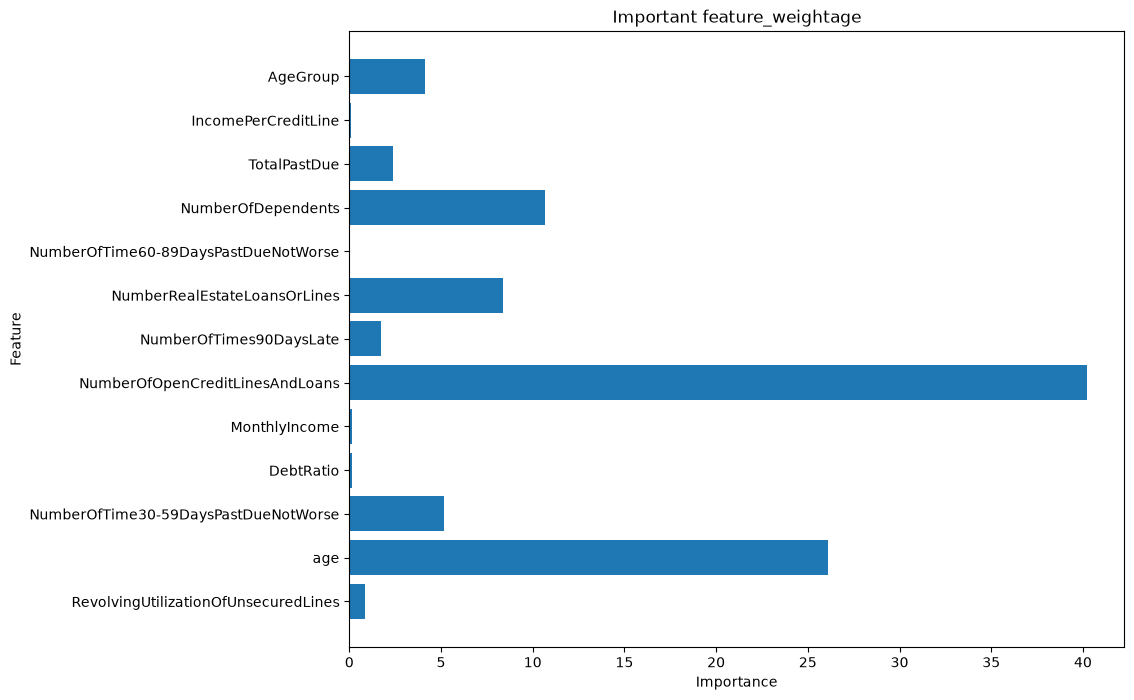

In [165]:
plt.figure(figsize=(10,8))
plt.barh(feature_weightage["Feature"], feature_weightage["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Important feature_weightage")
plt.show()

In [166]:
X_val_transformed = pipe4.named_steps["preprocessor"].transform(
    pipe4.named_steps["feature_engineering"].transform(x_test)
)
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_val_transformed)

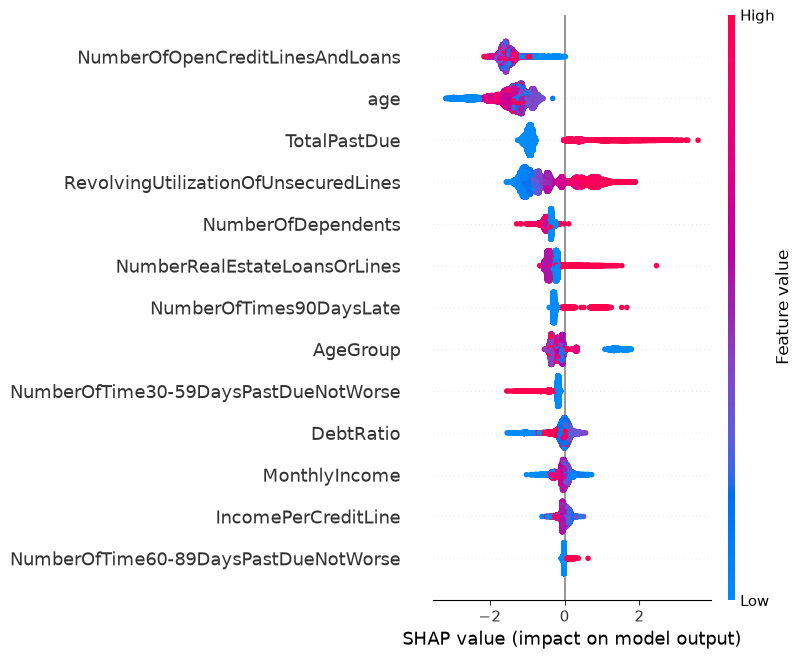

In [167]:
shap.summary_plot(
    shap_values,
    X_val_transformed,
    feature_names=feature_names
)

In [168]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.54      0.24      0.33      2005

    accuracy                           0.94     30000
   macro avg       0.74      0.61      0.65     30000
weighted avg       0.92      0.94      0.92     30000



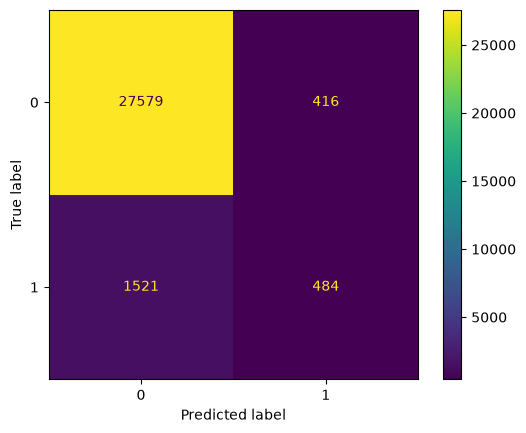

In [169]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

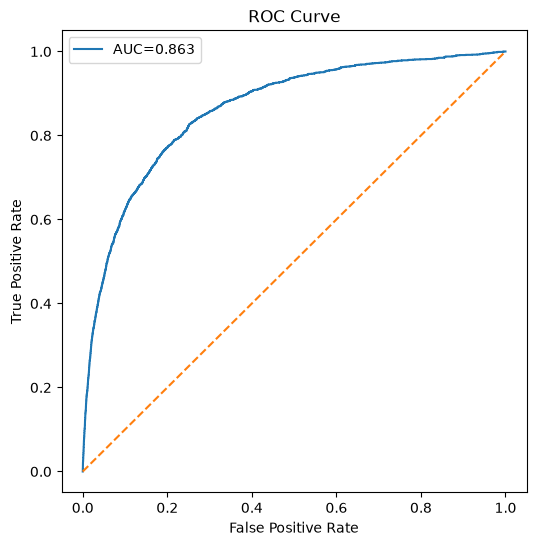

In [170]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f"AUC={roc_auc_score(y_test,y_prob):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [171]:
test_df = pd.read_csv("cs-testing.csv", index_col=0)

In [172]:
x_test_data = test_df.drop("SeriousDlqin2yrs", axis=1)
predictions = pipe4.predict_proba(x_test_data)[:, 1]

In [346]:
submission = pd.DataFrame({
    "Id": range(1, len(predictions) + 1),
    "Probability": predictions,
})

submission.to_csv("catboost_submission.csv", index=False)

In [173]:
result = pd.read_csv("catboost_submission.csv")
print(result)

            Id  Probability
0            1     0.127068
1            2     0.069163
2            3     0.025104
3            4     0.117845
4            5     0.118926
...        ...          ...
101498  101499     0.142573
101499  101500     0.334395
101500  101501     0.010480
101501  101502     0.038860
101502  101503     0.082635

[101503 rows x 2 columns]


In [174]:
result.isnull().sum()

Id             0
Probability    0
dtype: int64

In [123]:
import joblib

joblib.dump(pipe4, "credit_risk_model.joblib")
print("Saved pipeline to credit_risk_model.joblib")

Saved pipeline to credit_risk_model.joblib


In [176]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .ipynb_checkpoints/Give_credit-checkpoint.ipynb
	modified:   Give_credit.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/app-checkpoint.py
	.ipynb_checkpoints/feature_engineering-checkpoint.py
	.ipynb_checkpoints/frontend-checkpoint.py
	README.md
	__pycache__/
	app.py
	catboost_info/
	credit_risk_model.joblib
	feature_engineering.py
	frontend.py
	requirements.txt

no changes added to commit (use "git add" and/or "git commit -a")
